In [1]:
import os
import json
import random
import time
import copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics

DATASET_ROOT = Path("..") / "smartvision_dataset"
NEW_CLASSIFICATION_DIR = DATASET_ROOT / "classification_v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "val", transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "test", transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 25 | Train: 1750 | Val: 375 | Test: 375


In [3]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze everything first
for param in resnet50.parameters():
    param.requires_grad = False

# Unfreeze layer4 (the last residual block, ~20 layers) for fine-tuning
for param in resnet50.layer4.parameters():
    param.requires_grad = True

# Replace the final fc layer (ResNet already has global average pooling built in via .avgpool)
# Keeping the head simple, following what worked for VGG16 (avoids overfitting on 1750 images)
resnet50.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(2048, NUM_CLASSES)
)

resnet50 = resnet50.to(device)

# Confirm what's trainable
trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet50.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


Trainable params: 15,015,961 / 23,559,257


In [4]:
criterion = nn.CrossEntropyLoss()

# Lower LR for the pretrained (fine-tuned) layer4, higher LR for the fresh head
optimizer = optim.Adam([
    {"params": resnet50.layer4.parameters(), "lr": 1e-5, "weight_decay": 1e-4},
    {"params": resnet50.fc.parameters(), "lr": 1e-3, "weight_decay": 1e-4},
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("Optimizer ready with differential learning rates.")

Optimizer ready with differential learning rates.


In [5]:
EPOCHS = 10
best_val_acc = 0.0
best_model_weights = copy.deepcopy(resnet50.state_dict())
patience = 5
epochs_no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    start_time = time.time()

    # ---- Training phase ----
    resnet50.train()
    running_loss, running_correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    # ---- Validation phase ----
    resnet50.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(resnet50.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

resnet50.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/10 (57.8s) - train_loss: 2.4881, train_acc: 0.3023, val_loss: 1.4804, val_acc: 0.6080
Epoch 2/10 (57.7s) - train_loss: 1.3323, train_acc: 0.6331, val_loss: 1.0197, val_acc: 0.7253
Epoch 3/10 (57.3s) - train_loss: 0.9427, train_acc: 0.7274, val_loss: 0.8305, val_acc: 0.7867
Epoch 4/10 (54.8s) - train_loss: 0.7492, train_acc: 0.7771, val_loss: 0.7808, val_acc: 0.7893
Epoch 5/10 (55.7s) - train_loss: 0.6044, train_acc: 0.8297, val_loss: 0.6785, val_acc: 0.8160
Epoch 6/10 (55.5s) - train_loss: 0.4640, train_acc: 0.8669, val_loss: 0.6447, val_acc: 0.8267
Epoch 7/10 (54.4s) - train_loss: 0.3633, train_acc: 0.8971, val_loss: 0.6258, val_acc: 0.8373
Epoch 8/10 (54.5s) - train_loss: 0.2953, train_acc: 0.9171, val_loss: 0.5772, val_acc: 0.8453
Epoch 9/10 (53.2s) - train_loss: 0.2533, train_acc: 0.9280, val_loss: 0.5909, val_acc: 0.8533
Epoch 10/10 (52.2s) - train_loss: 0.1888, train_acc: 0.9526, val_loss: 0.5852, val_acc: 0.8640

Best validation accuracy: 0.8640


In [6]:
os.makedirs("../models", exist_ok=True)
torch.save(resnet50.state_dict(), "../models/resnet50_best.pth")
print("Model saved to ../models/resnet50_best.pth")

resnet50.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = metrics.accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(metrics.classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Model saved to ../models/resnet50_best.pth

Test Accuracy: 0.8000

Classification Report:
               precision    recall  f1-score   support

     airplane       1.00      0.93      0.97        15
          bed       0.67      0.67      0.67        15
        bench       0.93      0.87      0.90        15
      bicycle       0.82      0.93      0.88        15
         bird       0.94      1.00      0.97        15
       bottle       1.00      0.67      0.80        15
         bowl       0.79      0.73      0.76        15
          bus       0.81      0.87      0.84        15
         cake       0.76      0.87      0.81        15
          car       0.64      0.47      0.54        15
          cat       1.00      0.87      0.93        15
        chair       0.65      0.87      0.74        15
        couch       0.65      0.87      0.74        15
          cow       0.78      0.93      0.85        15
          cup       1.00      0.73      0.85        15
          dog       0.94     

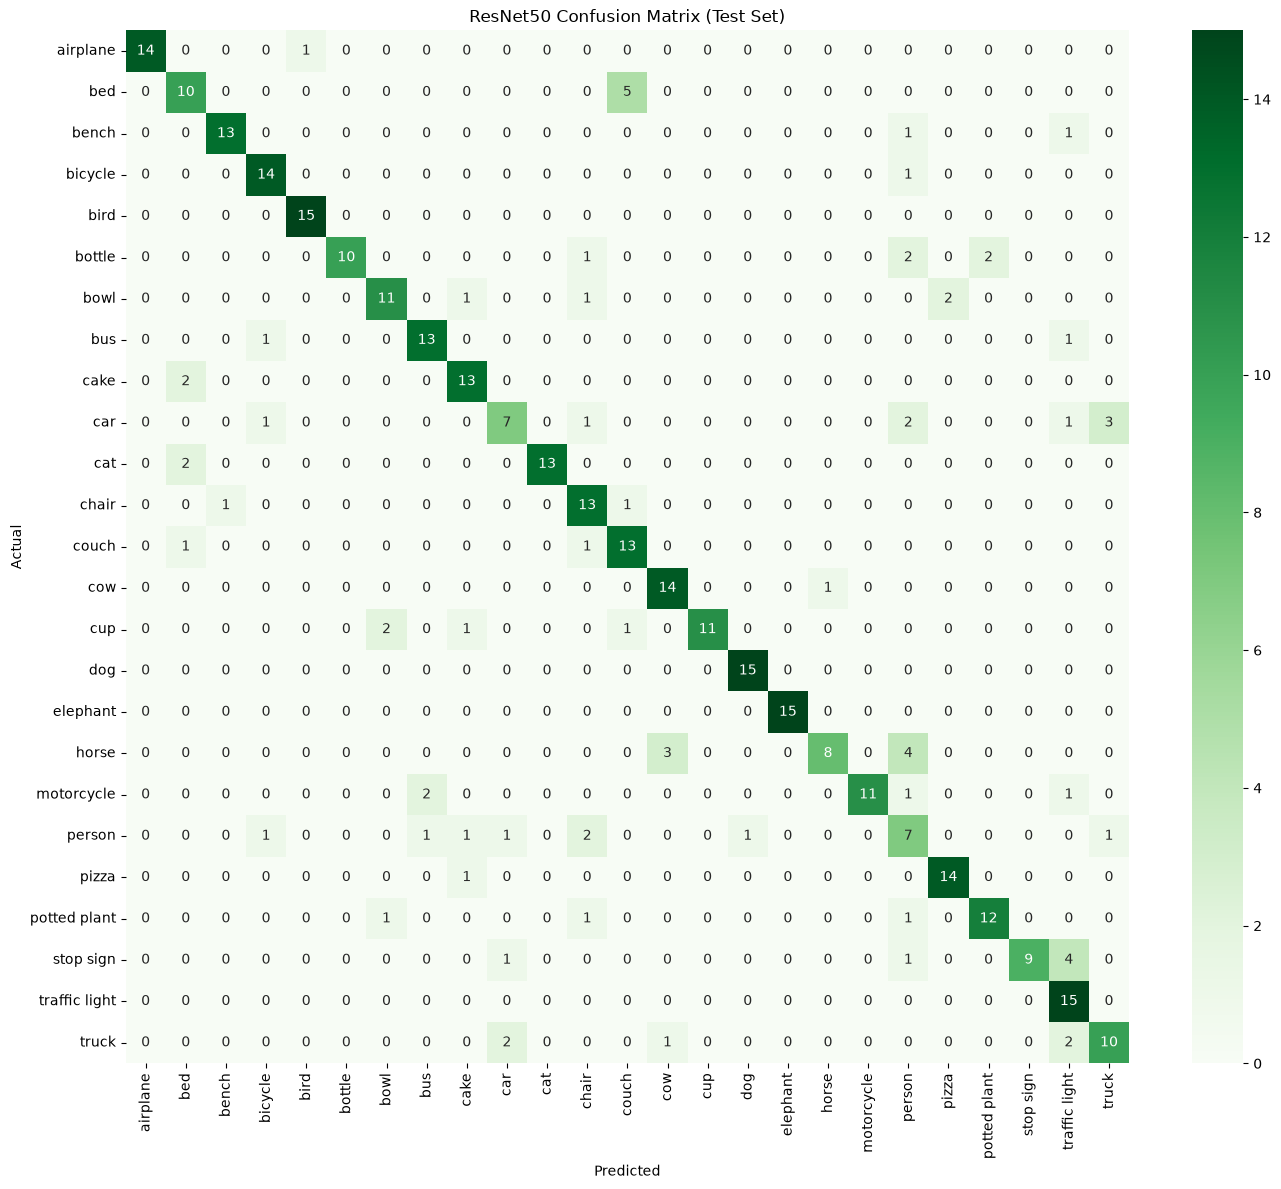

In [7]:
os.makedirs("../results/confusion_matrices", exist_ok=True)

cm = metrics.confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix (Test Set)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/confusion_matrices/resnet50_confusion_matrix.png")
plt.show()